# Data Preparation & Exploration

## Initialization


In [123]:
# loading all libraries
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt


## Load Data


In [124]:
# reading the main df
df = pd.read_csv('data/games.csv')


## Initial assessment


In [125]:
# initial assessment of the df
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


In [126]:
# viewing a sample of the data
print(df.sample(5))


                                           Name Platform  Year_of_Release  \
3541                                 Top Spin 3      PS3           2008.0   
11464  Slam 'n Jam '96 featuring Magic & Kareem       PS           1995.0   
2172                                     Kessen      PS2           2000.0   
16014                   Robopon 2: Ring Version      GBA           2001.0   
95       Crash Bandicoot 2: Cortex Strikes Back       PS           1997.0   

              Genre  NA_sales  EU_sales  JP_sales  Other_sales  Critic_Score  \
3541         Action      0.08      0.36      0.00         0.12          75.0   
11464        Sports      0.04      0.03      0.00         0.01           NaN   
2172       Strategy      0.27      0.21      0.41         0.07          75.0   
16014  Role-Playing      0.01      0.00      0.00         0.00          68.0   
95         Platform      3.78      2.17      1.31         0.31           NaN   

      User_Score Rating  
3541         7.5      E  
1146

In [127]:
# checking initial statistics of the numeric data
df.describe()


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


**Summary of the initial dataset assessment:**

The dataset consists of 16,715 rows and 11 columns.

**For the 'critic_score_max100' column:**
Considering the presence of older games in the sample, they were likely released before an online critic-score aggregation system existed.

**For the 'rating' column:**
The Rating column represents ESRB age ratings with the following criteria:
    * E — Everyone
    * E10+ — Ages 10 and up
    * T — Ages 13 and up
    * M — Ages 17 and up
    * AO — Adults only
    * RP — Rating pending
Since the current ESRB rating system only considers E, E10+, T, M, AO, and RP as valid categories, there are outdated rating values in the data.

**Required pre-processing:**

- column names need to be adjusted
- apparently missing values were noted and need to be investigated
- columns 2, 9, and 10 appear to have incorrect data types and need to be assessed
- 'Year_of_Release' needs its unit adjusted to 'int' or 'datetime' depending on the analysis to be performed

**Improvements to be implemented:**

- add a unit (millions) to the sales columns, max100 to critic_score, and max10 to user_score


## Pre-processing


#### Adjusting the header

- adjusting the title format
- including information in the titles


In [128]:
# checking the current column titles
print(df.columns)


Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='str')


In [129]:
# adjusting the header with a standard formatting protocol
new_col_names = []
for old_name in df.columns:
    name_stripped = old_name.strip()
    name_lowered = name_stripped.lower()
    name_no_spaces = name_lowered.replace(' ', '_')
    new_col_names.append(name_no_spaces)

df.columns = new_col_names


In [130]:
# renaming titles
df = df.rename(columns={'na_sales': 'na_sales_milions',
                       'eu_sales': 'eu_sales_milions',
                       'jp_sales': 'jp_sales_milions',
                        'other_sales': 'other_sales_milions',
                       'critic_score': 'critic_score_max100',
                       'user_score': 'user_score_max10'})


In [131]:
# checking the title changes
print(df.columns)


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales_milions',
       'eu_sales_milions', 'jp_sales_milions', 'other_sales_milions',
       'critic_score_max100', 'user_score_max10', 'rating'],
      dtype='str')


## Data preparation

- assess missing data
- assess duplicated data
- adjust data types
- calculate total sales


### Assess missing data


In [132]:
# checking the amount of explicitly missing data
print(df.isna().sum())


name                      2
platform                  0
year_of_release         269
genre                     2
na_sales_milions          0
eu_sales_milions          0
jp_sales_milions          0
other_sales_milions       0
critic_score_max100    8578
user_score_max10       6701
rating                 6766
dtype: int64


##### Assess missing data - 'name' column


In [133]:
# assessing the 'name' column
print(df[df['name'].isna()])


      name platform  year_of_release genre  na_sales_milions  \
659    NaN      GEN           1993.0   NaN              1.78   
14244  NaN      GEN           1993.0   NaN              0.00   

       eu_sales_milions  jp_sales_milions  other_sales_milions  \
659                0.53              0.00                 0.08   
14244              0.00              0.03                 0.00   

       critic_score_max100 user_score_max10 rating  
659                    NaN              NaN    NaN  
14244                  NaN              NaN    NaN  


In [134]:
# assessing the sales share of the game with an unknown name on row 14244
sale_14244 = df.loc[14244, 'jp_sales_milions']
total_sales_jp = df['jp_sales_milions'].sum()
print('The sales share of the game on row 14244 is',(sale_14244/total_sales_jp*100).round(2),'%')


The sales share of the game on row 14244 is 0.0 %


- row index 659 will have its name replaced with 'unknown' since this game has more than 2 million in sales.
- row 14244 will be dropped because it has a lot of unknown data and its sales total has no meaningful representation in the overall total.


In [135]:
# replacing the unknown name with 'unknown' on row 659
df.loc[659, 'name'] = 'unknown'


In [136]:
# dropping row 14244 (low representativeness in sales)
df = df.drop(index=14244).reset_index(drop=True)


In [137]:
# confirming the missing-value treatment for the 'name' column
print(df[df['name'].isna()])


Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales_milions, eu_sales_milions, jp_sales_milions, other_sales_milions, critic_score_max100, user_score_max10, rating]
Index: []


##### Assess missing data - 'year_of_release' column


In [138]:
# assessing the 'year_of_release' column
print(df['year_of_release'].value_counts(dropna=False))


year_of_release
2008.0    1427
2009.0    1426
2010.0    1255
2007.0    1197
2011.0    1136
2006.0    1006
2005.0     939
2002.0     829
2003.0     775
2004.0     762
2012.0     653
2015.0     606
2014.0     581
2013.0     544
2016.0     502
2001.0     482
1998.0     379
2000.0     350
1999.0     338
1997.0     289
NaN        269
1996.0     263
1995.0     219
1994.0     121
1993.0      61
1981.0      46
1992.0      43
1991.0      41
1982.0      36
1986.0      21
1989.0      17
1983.0      17
1990.0      16
1987.0      16
1988.0      15
1985.0      14
1984.0      14
1980.0       9
Name: count, dtype: int64


In [139]:
# removing missing values from the 'year_of_release' column to avoid creating an artificial spike in the releases-per-year chart
df = df.dropna(subset=['year_of_release']).reset_index(drop=True)


In [140]:
# confirming the missing-value treatment for the 'year_of_release' column
print(df[df['year_of_release'].isna()])


Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales_milions, eu_sales_milions, jp_sales_milions, other_sales_milions, critic_score_max100, user_score_max10, rating]
Index: []


##### Assess missing data - 'genre' column


In [141]:
# assessing the 'genre' column
print(df[df['genre'].isna()])


        name platform  year_of_release genre  na_sales_milions  \
652  unknown      GEN           1993.0   NaN              1.78   

     eu_sales_milions  jp_sales_milions  other_sales_milions  \
652              0.53               0.0                 0.08   

     critic_score_max100 user_score_max10 rating  
652                  NaN              NaN    NaN  


In [142]:
# replacing the unknown name with 'unknown' on row 659
#  (the game has more than 2 million in sales)
df.loc[659, 'genre'] = 'unknown'


In [143]:
# confirming the missing-value treatment for the 'genre' column
print(df[df['genre'].isna()])


        name platform  year_of_release genre  na_sales_milions  \
652  unknown      GEN           1993.0   NaN              1.78   

     eu_sales_milions  jp_sales_milions  other_sales_milions  \
652              0.53               0.0                 0.08   

     critic_score_max100 user_score_max10 rating  
652                  NaN              NaN    NaN  


##### Assess missing data - 'critic_score_max100' column


In [144]:
# assessing the 'critic_score_max100' column
print(df['critic_score_max100'].value_counts(dropna=False))


critic_score_max100
NaN     8462
70.0     252
71.0     248
75.0     240
80.0     235
        ... 
29.0       3
20.0       3
21.0       1
17.0       1
13.0       1
Name: count, Length: 82, dtype: int64


##### Assess missing data - 'user_score_max10' column


In [145]:
# assessing the column's data
print(df['user_score_max10'].value_counts(dropna=False))


user_score_max10
NaN    6606
tbd    2376
7.8     322
8       285
8.2     276
       ... 
0.6       2
0.9       2
1         2
0         1
9.7       1
Name: count, Length: 97, dtype: int64


In [146]:
# converting this column's data into numeric data
df['user_score_max10'] = pd.to_numeric(df['user_score_max10'], errors='coerce')


In [147]:
# re-assessing the column's data
print(df['user_score_max10'].value_counts(dropna=False))


user_score_max10
NaN    8982
7.8     322
8.0     285
8.2     276
8.3     252
       ... 
0.6       2
0.9       2
1.0       2
0.0       1
9.7       1
Name: count, Length: 96, dtype: int64


#### Assess missing data - 'rating' column


In [148]:
# assessing the column's data
print(df['rating'].value_counts(dropna=False))


rating
NaN     6677
E       3921
T       2905
M       1536
E10+    1393
EC         8
K-A        3
AO         1
RP         1
Name: count, dtype: int64


##### Summary of the missing-data treatment:

There are no explicitly missing values for the 'sales..' and 'platform' columns. Analyzing the remaining columns individually:

**For the 'name' column:**
The missing value was replaced with 'unknown' on row 659, while row 14244 was dropped due to low representativeness in sales.

**For the 'year_of_release' column:**
269 rows were removed to avoid creating an artificial spike in the releases-per-year chart (if filled with the mean) and to avoid placing a game that doesn't belong within the analysis period.

**For the 'genre' column:**
There was one missing value on row 659, which was replaced with 'unknown'.

**For the 'critic_score_max100' column:**
Explicit and implicit ('tbd') missing values were found, and because the column contained both strings and numbers, its data type was 'object'. Since 'tbd' means the score wasn't available at the time of data collection, it carries the same meaning as a missing value, and was treated as such to avoid distorting the data later on. The whole column was converted to a numeric type, handling the 'tbd' string that was affecting the missing-data assessment.

Approximately 50% of this column's data is missing, so filling it with the mean, median, or 0 (zero) would distort the analysis. Due to gaps in the collection and/or aggregation of this data at the source, these values will remain as 'NaN'. If needed for a specific analysis, further assessment can be done later and this data can be filtered.

**For the 'user_score_max10' column:**
Approximately 50% of this column's data is missing, so filling it with the mean, median, or 0 (zero) would distort the analysis. Due to gaps in the collection and/or aggregation of this data at the source, these values will remain as 'NaN'. If needed for a specific analysis, further assessment can be done later and this data can be filtered.

**For the 'rating' column:**
Approximately 40% of this column's data is missing, so filling it with the mean, median, or 0 (zero) would distort future analysis. Due to gaps in the collection and/or aggregation of this data at the source, these values will remain as 'NaN'. If needed for a specific analysis, further assessment can be done later and this data can be filtered.


* Creating a column based on 'rating' (converting the column's data to numeric) for future analysis


In [149]:
# creating a function to perform the transformation
def esrb_code(rating):
    """
    Returns a numeric code for the ESRB rating
    using the following rules:
    — 1   for 'rating' == 'E'
    — 2   for 'rating' == 'E10+'
    — 3   for 'rating' == 'T'
    — 4   for 'rating' == 'M'
    — 5   for 'rating' == 'AO'
    — 6   for 'rating' == 'RP'
    — 7   for 'rating' == 'EC'
    — 8   for 'rating' == 'K-A'
    """
    if rating == 'E':
        return 1
    elif rating == 'E10+':
        return 2
    elif rating == 'T':
        return 3
    elif rating == 'M':
        return 4
    elif rating == 'AO':
        return 5
    elif rating == 'RP':
        return 6
    elif rating == 'EC':
        return 7
    elif rating == 'K-A':
        return 8
    else:
        return pd.NA


In [150]:
# applying the function to create the new column
df['rating_code'] = df['rating'].apply(esrb_code).astype('Int64')
print(df.head())


                       name platform  year_of_release         genre  \
0                Wii Sports      Wii           2006.0        Sports   
1         Super Mario Bros.      NES           1985.0      Platform   
2            Mario Kart Wii      Wii           2008.0        Racing   
3         Wii Sports Resort      Wii           2009.0        Sports   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   

   na_sales_milions  eu_sales_milions  jp_sales_milions  other_sales_milions  \
0             41.36             28.96              3.77                 8.45   
1             29.08              3.58              6.81                 0.77   
2             15.68             12.76              3.79                 3.29   
3             15.61             10.93              3.28                 2.95   
4             11.27              8.89             10.22                 1.00   

   critic_score_max100  user_score_max10 rating  rating_code  
0                 76.0       

### Assess duplicated data


In [151]:
# counting explicitly duplicated values
print('Number of fully duplicated rows:',df.duplicated().sum())


Number of fully duplicated rows: 0


In [152]:
# checking duplicated values for the 'name' column
print('Number of unique titles in the name column:',df['name'].nunique())
print('\nNumber of rows in the DataFrame:', len(df))
print('\nThere are',
      len(df) - df['name'].nunique(),
      'duplicated titles in the name column')


Number of unique titles in the name column: 11427

Number of rows in the DataFrame: 16445

There are 5018 duplicated titles in the name column


In [153]:
# investigating the occurrence of repeated titles
print('LIST OF REPEATED TITLES IN THE NAME COLUMN\n',df['name'].value_counts())


LIST OF REPEATED TITLES IN THE NAME COLUMN
 name
Need for Speed: Most Wanted           12
FIFA 14                                9
LEGO Marvel Super Heroes               9
Ratatouille                            9
FIFA Soccer 13                         8
                                      ..
15 Days                                1
Aiyoku no Eustia                       1
Woody Woodpecker in Crazy Castle 5     1
LMA Manager 2007                       1
Haitaka no Psychedelica                1
Name: count, Length: 11427, dtype: int64


In [154]:
# printing a filtered df with the most frequently repeated title in the 'name' column
print('LIST WITH THE MAIN REPEATED TITLE IN THE NAME COLUMN:\n',
      df[df['name']=='Need for Speed: Most Wanted'])


LIST WITH THE MAIN REPEATED TITLE IN THE NAME COLUMN:
                               name platform  year_of_release   genre  \
252    Need for Speed: Most Wanted      PS2           2005.0  Racing   
519    Need for Speed: Most Wanted      PS3           2012.0  Racing   
1178   Need for Speed: Most Wanted     X360           2012.0  Racing   
1575   Need for Speed: Most Wanted     X360           2005.0  Racing   
1977   Need for Speed: Most Wanted       XB           2005.0  Racing   
2026   Need for Speed: Most Wanted      PSV           2012.0  Racing   
3532   Need for Speed: Most Wanted       GC           2005.0  Racing   
5884   Need for Speed: Most Wanted       PC           2005.0  Racing   
6178   Need for Speed: Most Wanted     WiiU           2013.0  Racing   
6311   Need for Speed: Most Wanted       DS           2005.0  Racing   
6374   Need for Speed: Most Wanted      GBA           2005.0  Racing   
11535  Need for Speed: Most Wanted       PC           2012.0  Racing   

       n

##### Summary of the duplicated-data treatment:

No fully duplicated rows were found, but there are duplicated titles in the 'name' column. However, these occurrences refer to games with the same name that were released on different platforms or under different circumstances (such as a different year), so they are not implicitly duplicated.


### Adjusting data types
- column 2 ('year_of_release') to 'int' or 'datetime' depending on the analysis to be performed.
- columns 9 and 10 appear to have incorrect data types and need to be assessed


In [155]:
# re-checking data type consistency after manipulation
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 16445 entries, 0 to 16444
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 16445 non-null  str    
 1   platform             16445 non-null  str    
 2   year_of_release      16445 non-null  float64
 3   genre                16444 non-null  str    
 4   na_sales_milions     16445 non-null  float64
 5   eu_sales_milions     16445 non-null  float64
 6   jp_sales_milions     16445 non-null  float64
 7   other_sales_milions  16445 non-null  float64
 8   critic_score_max100  7983 non-null   float64
 9   user_score_max10     7463 non-null   float64
 10  rating               9768 non-null   str    
 11  rating_code          9768 non-null   Int64  
dtypes: Int64(1), float64(7), str(4)
memory usage: 1.5 MB


- column 2 needs its data type adjusted to 'int'


In [156]:
# converting column 2's data to 'int'
df['year_of_release'] = df['year_of_release'].astype('int')


In [157]:
# confirming the change
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 16445 entries, 0 to 16444
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 16445 non-null  str    
 1   platform             16445 non-null  str    
 2   year_of_release      16445 non-null  int64  
 3   genre                16444 non-null  str    
 4   na_sales_milions     16445 non-null  float64
 5   eu_sales_milions     16445 non-null  float64
 6   jp_sales_milions     16445 non-null  float64
 7   other_sales_milions  16445 non-null  float64
 8   critic_score_max100  7983 non-null   float64
 9   user_score_max10     7463 non-null   float64
 10  rating               9768 non-null   str    
 11  rating_code          9768 non-null   Int64  
dtypes: Int64(1), float64(6), int64(1), str(4)
memory usage: 1.5 MB


##### Summary of the data-type adjustment:

The data types were adjusted for proper handling and analysis. The 'year_of_release' column had its type changed to integer, and the 'user_score_max10' column was naturally adjusted to 'float' during the 'tbd' treatment. The 'rating' column was confirmed to already have a type appropriate to its content.


### Calculate total sales


In [158]:
# creating a column with the sum of sales across all regions

df['total_sales_milions'] = (df['na_sales_milions'] +
                             df['eu_sales_milions'] +
                             df['jp_sales_milions'] +
                             df['other_sales_milions'])


In [159]:
print(df.head())


                       name platform  year_of_release         genre  \
0                Wii Sports      Wii             2006        Sports   
1         Super Mario Bros.      NES             1985      Platform   
2            Mario Kart Wii      Wii             2008        Racing   
3         Wii Sports Resort      Wii             2009        Sports   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   

   na_sales_milions  eu_sales_milions  jp_sales_milions  other_sales_milions  \
0             41.36             28.96              3.77                 8.45   
1             29.08              3.58              6.81                 0.77   
2             15.68             12.76              3.79                 3.29   
3             15.61             10.93              3.28                 2.95   
4             11.27              8.89             10.22                 1.00   

   critic_score_max100  user_score_max10 rating  rating_code  \
0                 76.0      

# Data Analysis


### How many games were released each year?


In [160]:
# creating a df with the number of games grouped by year
df_year = (
    df.groupby('year_of_release')['name'].count()
    .reset_index()
    .rename(columns={'name': 'count'})
)
print('Table with the number of games per year\n\n', df_year)


Table with the number of games per year

     year_of_release  count
0              1980      9
1              1981     46
2              1982     36
3              1983     17
4              1984     14
5              1985     14
6              1986     21
7              1987     16
8              1988     15
9              1989     17
10             1990     16
11             1991     41
12             1992     43
13             1993     61
14             1994    121
15             1995    219
16             1996    263
17             1997    289
18             1998    379
19             1999    338
20             2000    350
21             2001    482
22             2002    829
23             2003    775
24             2004    762
25             2005    939
26             2006   1006
27             2007   1197
28             2008   1427
29             2009   1426
30             2010   1255
31             2011   1136
32             2012    653
33             2013    544
34           

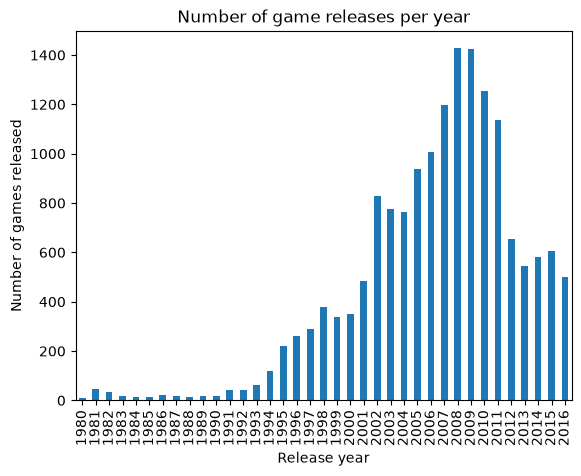

In [161]:
# creating a chart with the number of games per year
df_year.plot(x='year_of_release', kind='bar',
            title='Number of game releases per year',
            xlabel='Release year',
            ylabel='Number of games released',
            legend=False)
plt.show()


There's an early period with few games released in 1980, showing weak growth, and starting in 1991 a growth trend in game releases begins, confirmed by 1995, reaching a peak around 2008-2009. Afterward, releases decline to a plateau starting in 2012.


### How did sales vary from platform to platform?


#### Choosing the platforms with the highest total sales to build a distribution based on the data for each year


* Choosing the platforms with the highest sales


In [162]:
# choosing the platforms with the highest total sales
df_p1 = (df.groupby('platform')['total_sales_milions'].sum().reset_index())

# sorting total sales
df_p1 = (
    df_p1.sort_values('total_sales_milions', ascending=False)
    .reset_index(drop=True)
)

# selection criteria for the highest-revenue platforms
minimum = 0.01

# applying the selection criteria for the highest-revenue platforms
df_p1 = df_p1[df_p1['total_sales_milions'] >= minimum * df_p1['total_sales_milions'].max()]

print('SELECTION OF PLATFORMS WITH THE HIGHEST SALES:\n\n', df_p1)


SELECTION OF PLATFORMS WITH THE HIGHEST SALES:

    platform  total_sales_milions
0       PS2              1233.56
1      X360               961.24
2       PS3               931.34
3       Wii               891.18
4        DS               802.78
5        PS               727.58
6       PS4               314.14
7       GBA               312.88
8       PSP               289.53
9       3DS               257.81
10       PC               255.76
11       GB               254.43
12       XB               251.57
13      NES               251.05
14      N64               218.01
15     SNES               200.04
16       GC               196.73
17     XOne               159.32
18     2600                86.48
19     WiiU                82.19
20      PSV                53.81
21      SAT                33.59
22      GEN                30.74
23       DC                15.95


In [163]:
print('- the selected platforms are those whose total revenue was at least',
      minimum * 100, '% of the top-revenue platform.\n')
print('- we will use', len(df_p1),
      'platforms, with the lowest-revenue one being',
      df_p1['platform'].iloc[-1], '\nwith total revenue of',
      df_p1['total_sales_milions'].iloc[-1].round(2), 'million units sold.')


- the selected platforms are those whose total revenue was at least 1.0 % of the top-revenue platform.

- we will use 24 platforms, with the lowest-revenue one being DC 
with total revenue of 15.95 million units sold.


* Building a distribution based on the data for each year


In [164]:
# creating a df without the low-revenue platforms
plat_remove = ['SCD', 'NG', 'WS', 'TG16', '3DO', 'GG', 'PCFX']

df_platform = df[~df['platform'].isin(plat_remove)].reset_index(drop=True)


In [165]:
# building a distribution based on platform sales data for each year
sales_year = df_platform.pivot_table(index='year_of_release',
                                   columns='platform',
                                   values='total_sales_milions',
                                   aggfunc='sum')
print(sales_year)


platform          2600    3DS    DC      DS     GB    GBA     GC    GEN  \
year_of_release                                                           
1980             11.38    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1981             35.68    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1982             28.88    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1983              5.84    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1984              0.27    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1985              0.45    NaN   NaN    0.02    NaN    NaN    NaN    NaN   
1986              0.67    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1987              1.94    NaN   NaN     NaN    NaN    NaN    NaN    NaN   
1988              0.74    NaN   NaN     NaN   1.43    NaN    NaN    NaN   
1989              0.63    NaN   NaN     NaN  64.97    NaN    NaN    NaN   
1990               NaN    NaN   NaN     NaN   4.89    NaN    NaN   2.60   
1991               NaN   

#### Finding platforms that used to be popular but now have no sales


In [166]:
# selecting the sales period for the last 5 years (2012-2016)
recent_years = sales_year.loc[2012:2016]

# finding platforms that no longer have sales in the recent period
platforms_no_recent_sales = recent_years.columns[recent_years.isna().all()]

# of the platforms without recent sales, which ones had significant sales at some point
peak_sales = (
    sales_year[platforms_no_recent_sales].max()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'total_sales_milions'})
)

print('THESE ARE THE PLATFORMS THAT USED TO BE POPULAR, BUT NO LONGER SELL:\n\n',
      peak_sales)


THESE ARE THE PLATFORMS THAT USED TO BE POPULAR, BUT NO LONGER SELL:

    platform  total_sales_milions
0       PS2               211.81
1        PS               169.49
2       GBA                77.91
3        XB                65.42
4        GB                64.97
5       N64                57.87
6       NES                53.44
7        GC                51.81
8      SNES                40.02
9      2600                35.68
10      GEN                12.64
11      SAT                11.57
12       DC                 5.99


### How long does it take for new platforms to appear and old ones to disappear?


In [167]:
# creating a df with the first and last year of sales for each platform
platform_life = pd.DataFrame({
    'first_year': sales_year.apply(lambda col: col.first_valid_index()),
    'last_year': sales_year.apply(lambda col: col.last_valid_index())
})
print(platform_life)


          first_year  last_year
platform                       
2600            1980       1989
3DS             2011       2016
DC              1998       2008
DS              1985       2013
GB              1988       2001
GBA             2000       2007
GC              2001       2007
GEN             1990       1994
N64             1996       2002
NES             1983       1994
PC              1985       2016
PS              1994       2003
PS2             2000       2011
PS3             2006       2016
PS4             2013       2016
PSP             2004       2015
PSV             2011       2016
SAT             1994       1999
SNES            1990       1999
Wii             2006       2016
WiiU            2012       2016
X360            2005       2016
XB              2000       2008
XOne            2013       2016


In [168]:
# adding a column with each platform's lifespan calculation
platform_life['duration_life'] = platform_life['last_year'] - platform_life['first_year']
print('Table with platform lifespans:\n\n',platform_life)


Table with platform lifespans:

           first_year  last_year  duration_life
platform                                      
2600            1980       1989              9
3DS             2011       2016              5
DC              1998       2008             10
DS              1985       2013             28
GB              1988       2001             13
GBA             2000       2007              7
GC              2001       2007              6
GEN             1990       1994              4
N64             1996       2002              6
NES             1983       1994             11
PC              1985       2016             31
PS              1994       2003              9
PS2             2000       2011             11
PS3             2006       2016             10
PS4             2013       2016              3
PSP             2004       2015             11
PSV             2011       2016              5
SAT             1994       1999              5
SNES            1990       

In [169]:
# finding the statistical data for platform lifespans
platform_life['duration_life'].describe()


count    24.000000
mean      9.541667
std       6.807791
min       3.000000
25%       5.000000
50%       9.000000
75%      11.000000
max      31.000000
Name: duration_life, dtype: float64

In [170]:
print('- a platform\'s lifespan ranges from',
      platform_life['duration_life'].min(), 'to',
      platform_life['duration_life'].max(), 'years.\n')

print('- the average platform lifespan is',
      platform_life['duration_life'].mean().round(2), 'years.')


- a platform's lifespan ranges from 3 to 31 years.

- the average platform lifespan is 9.54 years.


### Selected data period


Considering the timeline, the period selected starts in 2013 (representing the consolidation of the sales plateau that remains current) through 2016, the most recent date available.

This way, it's possible to cover a period consistent with the confirmation of the current game-release trend.


### Selecting the most relevant data


* Selecting the time period


In [171]:
# selecting the data for the period of interest
df = df[df['year_of_release'] >= 2013]


* Selecting the data for platforms with sales in 2016


In [172]:
# summing each platform's sales in the period of interest
sales_2016 = df[df['year_of_release'] == 2016].groupby('platform')['total_sales_milions'].sum()

# getting a list of platforms that had sales in 2016
platforms_with_2016_sales = sales_2016[sales_2016 > 0].index

# applying the filter to the entire df
df = df[df['platform'].isin(platforms_with_2016_sales)].reset_index(drop=True)


In [173]:
# assessing total revenue by platform in the selected period
top_platforms = (df.groupby('platform')['total_sales_milions'].sum().reset_index())

# sorting total sales
top_platforms = (
    top_platforms.sort_values('total_sales_milions', ascending=False)
    .reset_index(drop=True)
)

#print('Total platform revenue from 2013 to 2016\n\n',top_platforms)


* Assessing the new df with the selected parameters


In [174]:
df.info()
print('\n-', len(df), 'rows and', len(df.columns), 'columns.')
print('- missing data handled (specific cases explained in the corresponding section).')
print('- no duplicated data in the df.')
print('- period from', df['year_of_release'].min(), 'to',
      df['year_of_release'].max(), 'years.')
print('- platform with the lowest total revenue in the period:',
      top_platforms['total_sales_milions'].min(), 'million.')


<class 'pandas.DataFrame'>
RangeIndex: 2158 entries, 0 to 2157
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 2158 non-null   str    
 1   platform             2158 non-null   str    
 2   year_of_release      2158 non-null   int64  
 3   genre                2158 non-null   str    
 4   na_sales_milions     2158 non-null   float64
 5   eu_sales_milions     2158 non-null   float64
 6   jp_sales_milions     2158 non-null   float64
 7   other_sales_milions  2158 non-null   float64
 8   critic_score_max100  990 non-null    float64
 9   user_score_max10     1189 non-null   float64
 10  rating               1247 non-null   str    
 11  rating_code          1247 non-null   Int64  
 12  total_sales_milions  2158 non-null   float64
dtypes: Int64(1), float64(7), int64(1), str(4)
memory usage: 221.4 KB

- 2158 rows and 13 columns.
- missing data handled (specific cases explained in the

### Which platforms are leading in sales?


In [175]:
# selecting the top 5 platforms by revenue
print('Leading platforms in total sales:\n\n', top_platforms.head(5))


Leading platforms in total sales:

   platform  total_sales_milions
0      PS4               314.14
1      PS3               181.43
2     XOne               159.32
3      3DS               143.25
4     X360               136.80


### Which ones are growing or declining?


In [176]:
# new sales distribution (2013 to 2016)
sales_year_final = df.pivot_table(index='year_of_release',
                                 columns='platform',
                                 values='total_sales_milions',
                                 aggfunc='sum')

print(sales_year_final)


platform           3DS     PC     PS3     PS4    PSV   Wii   WiiU   X360  \
year_of_release                                                            
2013             56.57  12.38  113.25   25.99  10.59  8.59  21.65  88.58   
2014             43.76  13.28   47.76  100.00  11.90  3.75  22.03  34.74   
2015             27.78   8.52   16.82  118.90   6.25  1.14  16.35  11.96   
2016             15.14   5.25    3.60   69.25   4.25  0.18   4.60   1.52   

platform          XOne  
year_of_release         
2013             18.96  
2014             54.07  
2015             60.14  
2016             26.15  


In [177]:
# comparing average sales across two recent periods to assess the trend
period_early = sales_year_final.loc[2013:2014].mean()
period_late = sales_year_final.loc[2015:2016].mean()


In [178]:
# creating the trend df
trend = pd.DataFrame({
    'avg_2013_2014': period_early,
    'avg_2015_2016': period_late
})

print(trend.head())


          avg_2013_2014  avg_2015_2016
platform                              
3DS              50.165         21.460
PC               12.830          6.885
PS3              80.505         10.210
PS4              62.995         94.075
PSV              11.245          5.250


In [179]:
# calculating the trend variation
trend['variation_milions'] = trend['avg_2015_2016'] - trend['avg_2013_2014']


In [180]:
# assessing whether the trend is increasing or decreasing
trend['trend'] = trend['variation_milions'].apply(
    lambda x: 'growing' if x > 0 else ('declining' if x < 0 else 'stable')
)


In [181]:
# sorting by trend variation
trend = trend.sort_values('variation_milions', ascending=False)

print('Assessment of platform revenue trend\n\n',trend)
print('\n- of the platforms with revenue between 2013 and 2016, only',
      trend.index[0], 'and', trend.index[1],
       '\nshowed a growth trend in revenue.')


Assessment of platform revenue trend

           avg_2013_2014  avg_2015_2016  variation_milions      trend
platform                                                            
PS4              62.995         94.075             31.080    growing
XOne             36.515         43.145              6.630    growing
Wii               6.170          0.660             -5.510  declining
PC               12.830          6.885             -5.945  declining
PSV              11.245          5.250             -5.995  declining
WiiU             21.840         10.475            -11.365  declining
3DS              50.165         21.460            -28.705  declining
X360             61.660          6.740            -54.920  declining
PS3              80.505         10.210            -70.295  declining

- of the platforms with revenue between 2013 and 2016, only PS4 and XOne 
showed a growth trend in revenue.


### Select several potentially profitable platforms

The potentially profitable platforms selected for 2016 were PS4 and XOne


### Build a box plot for global sales of all games, split by platform.


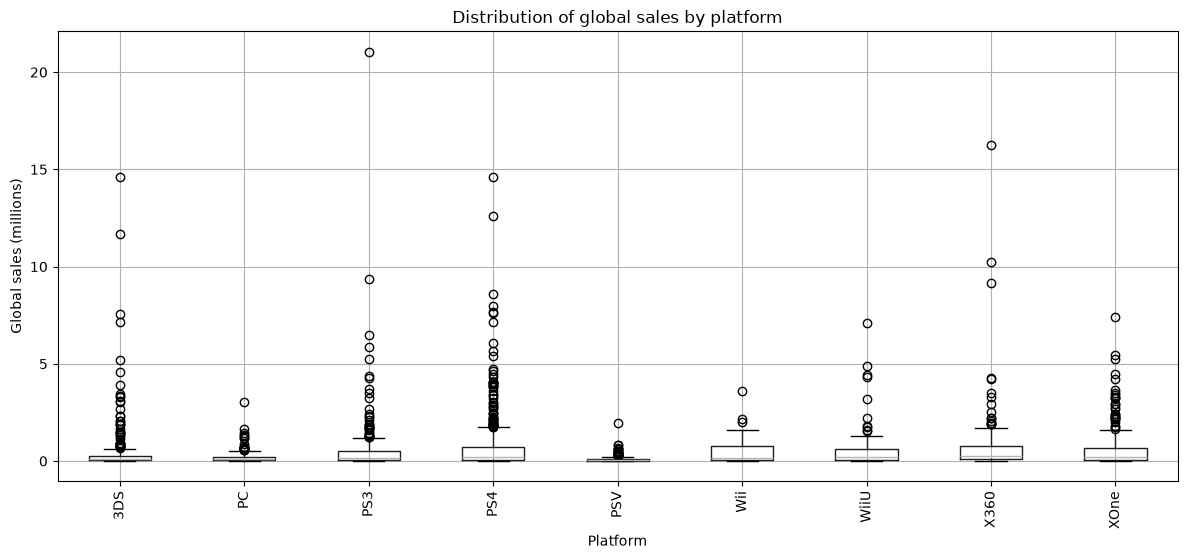

In [182]:
# building a box plot of global sales by platform
df.boxplot(column='total_sales_milions', by='platform', figsize=(14,6), rot=90)
plt.title('Distribution of global sales by platform')
plt.suptitle('')
plt.xlabel('Platform')
plt.ylabel('Global sales (millions)')
plt.show()


##### Initial chart assessment

All platforms have many outliers, driven by games that were more successful than others.

In this view, one particular PS3 game distorts the entire chart, making it impossible to do a more detailed analysis of averages and sales. This chart was kept to highlight the occurrence of this issue.


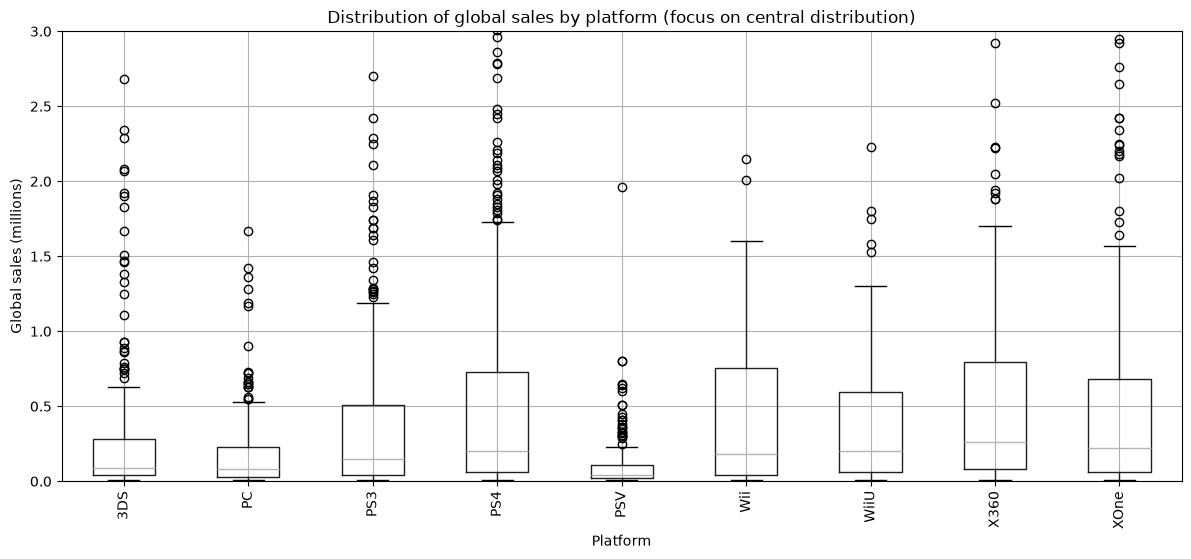

In [183]:
# same box plot, with the y-axis limited for a better view of the central distribution
df.boxplot(column='total_sales_milions', by='platform', figsize=(14,6), rot=90)
plt.title('Distribution of global sales by platform (focus on central distribution)')
plt.suptitle('')
plt.xlabel('Platform')
plt.ylabel('Global sales (millions)')
plt.ylim(0, 3)
plt.show()


In [184]:
# descriptive sales statistics by platform
platform_sales_stats = df.groupby('platform')['total_sales_milions'].agg(
    ['mean', 'median', 'std', 'max', 'count']
).sort_values('mean', ascending=False)

print('Descriptive sales statistics by platform\n\n',platform_sales_stats)


Descriptive sales statistics by platform

               mean  median       std    max  count
platform                                          
PS4       0.801378   0.200  1.609456  14.63    392
X360      0.735484   0.265  1.663275  16.27    186
XOne      0.645020   0.220  1.036139   7.39    247
Wii       0.593913   0.180  0.915432   3.58     23
WiiU      0.562000   0.200  1.038778   7.09    115
PS3       0.525884   0.150  1.451939  21.05    345
3DS       0.472772   0.090  1.381347  14.60    303
PC        0.208624   0.080  0.352304   3.05    189
PSV       0.092151   0.040  0.153816   1.96    358


##### Final chart assessment

It's possible to see that the platforms that are (or once were) market leaders tend to have higher averages and boxes, as well as more extreme outliers. On the other hand, platforms with a more niche audience show more compact distributions closer to zero.

Analyzing the difference in sales through the box plot and the descriptive statistics shown, it's possible to confirm that, overall, most games on any platform sell relatively little (low medians, generally below 0.5 million), while a few "outlier" games sell tens of millions. Because of this, the first box plot shown appeared "flattened."


### Are the differences in sales significant?


#### Kruskal-Wallis test to assess whether the difference in sales is significant

* The Kruskal-Wallis test is more appropriate for this study, since the sales data shows strong right skew, deviating from a normal distribution.


**Hypotheses**

* $H_0$ = The sales difference has the same distribution
* $H_1$ = At least one group shows a different sales distribution

**Parameters**

* alpha = 0.05


In [185]:
# preparing the sales groups by platform for the test
groups = [
    group['total_sales_milions'].dropna().values
          for _, group in df.groupby('platform')
]


In [186]:
# applying the Kruskal-Wallis test
h_stat, p_value = st.kruskal(*groups)
print(f'H statistic: {h_stat:.2f}, p-value: {p_value:.4f}')


H statistic: 252.38, p-value: 0.0000


**Significance assessment**

To determine whether the differences in sales were significant, the Kruskal-Wallis test was applied. It showed that the p-value (0.0000) was lower than the previously established alpha (0.05), indicating that the difference between platform distributions is statistically significant — that is, one platform's distribution differs from the others.


### What about average sales across various platforms?


When comparing the mean and the median, the existing skew becomes evident.

The best-selling games pull the revenue average upward, which is why the mean tends to be much higher than the median for virtually every platform.

Because of this, it's incorrect to use average sales as the central metric for this project. The median is more representative of the 'typical' game.


### Investigating how user and professional reviews affect sales on one of the popular platforms (your choice).

* PS4 was chosen for having strong revenue, a good sample size, and because it's growing in the market.


In [187]:
# filtering the df to get data for the PS4 platform
df_ps4 = df[df['platform'] == 'PS4'][['total_sales_milions',
                                      'critic_score_max100', 'user_score_max10']]

print(df_ps4.info())


<class 'pandas.DataFrame'>
Index: 392 entries, 2 to 2120
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   total_sales_milions  392 non-null    float64
 1   critic_score_max100  252 non-null    float64
 2   user_score_max10     257 non-null    float64
dtypes: float64(3)
memory usage: 12.2 KB
None


In [188]:
print(' - The df has', len(df), 'rows and',len(df.columns), 'columns.\n',
      '- There are',len(df),
      'PS4 game samples released between 2013 and 2016')


 - The df has 2158 rows and 13 columns.
 - There are 2158 PS4 game samples released between 2013 and 2016


* Building a scatter plot and calculating the correlation between reviews and sales.


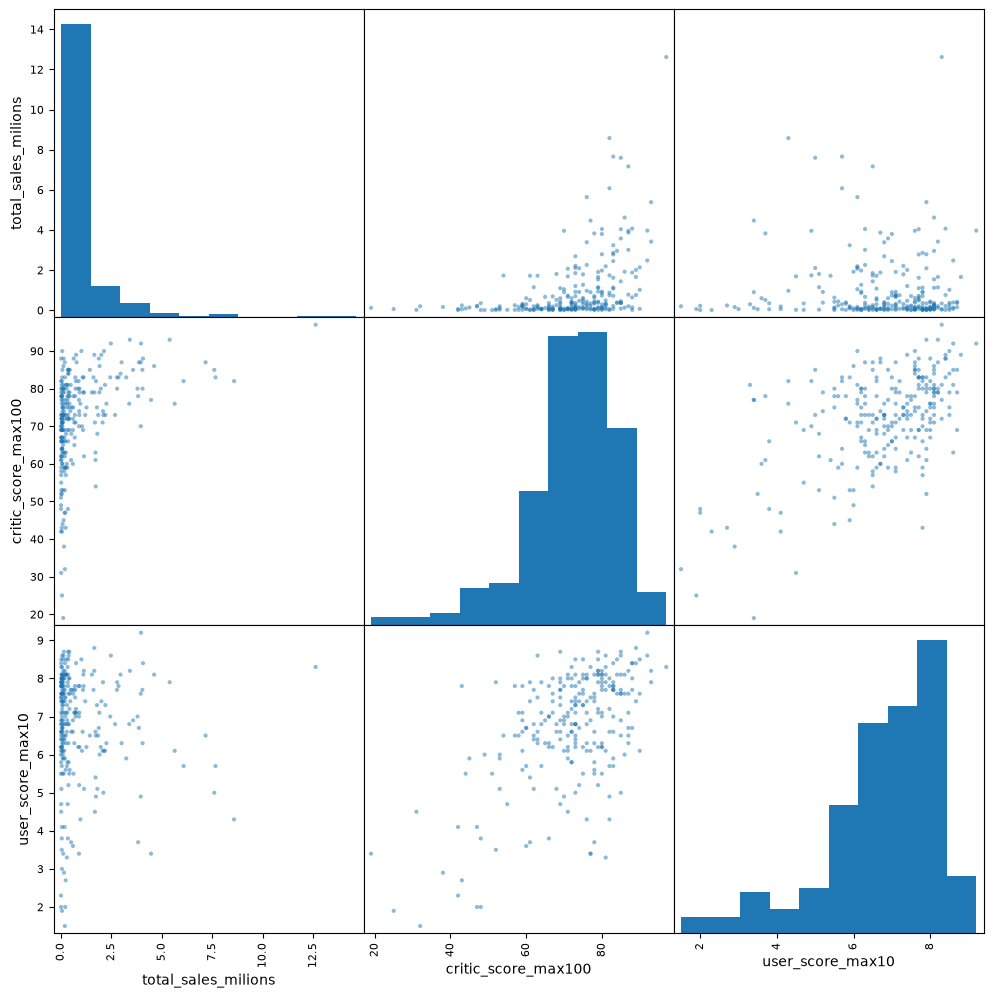

In [189]:
# building a scatter plot
pd.plotting.scatter_matrix(df_ps4, figsize=(12,12))
plt.show()


**Scatter plot analysis**

Analyzing PS4 sales against user reviews through the scatter plot, it's possible to notice a weak relationship between reviews and sales.

Analyzing PS4 sales against professional reviews through the scatter plot, it's possible to notice a moderate positive relationship between reviews and sales.


In [190]:
# calculating the correlation between reviews and sales
print(df_ps4.corr().round(2))


                     total_sales_milions  critic_score_max100  \
total_sales_milions                 1.00                 0.41   
critic_score_max100                 0.41                 1.00   
user_score_max10                   -0.03                 0.56   

                     user_score_max10  
total_sales_milions             -0.03  
critic_score_max100              0.56  
user_score_max10                 1.00  


**Analyzing the correlations**

When the relationship between user reviews and PS4 sales is calculated via the correlation coefficient, a value of 0.03 is found. This confirms the initial visual assessment from the scatter plot. It's therefore possible to infer that user reviews have very little to no effect on PS4 sales.

When the relationship between professional reviews and PS4 sales is calculated via the correlation coefficient, a value of 0.41 is found. This points to a moderate correlation (above 0.3) and shows a stronger relationship than what the visual assessment via the scatter plot suggested. It's therefore possible to infer that professional reviews moderately affect PS4 sales.

Professional reviews likely carry more weight in customers' purchasing decisions.


### Comparing sales of the same games on other platforms.


In [191]:
# identifying 5 games that were released on more than one platform
print(df['name'].value_counts())


name
FIFA 14                         8
FIFA 15                         8
LEGO Marvel Super Heroes        8
The LEGO Movie Videogame        8
Lego Batman 3: Beyond Gotham    8
                               ..
7'scarlet                       1
The Longest 5 Minutes           1
Strawberry Nauts                1
Aiyoku no Eustia                1
Haitaka no Psychedelica         1
Name: count, Length: 1210, dtype: int64


In [192]:
# creating a df with the 5 selected games
selected = ['LEGO Marvel Super Heroes', 'FIFA 14',
            'LEGO Jurassic World', 'FIFA 15', 'Angry Birds Star Wars']
df_5 = df[df['name'].isin(selected)]
print(df_5.head())


       name platform  year_of_release   genre  na_sales_milions  \
18  FIFA 14      PS3             2013  Sports              0.78   
19  FIFA 15      PS4             2014  Sports              0.80   
38  FIFA 15      PS3             2014  Sports              0.58   
40  FIFA 14     X360             2013  Sports              0.92   
74  FIFA 14      PS4             2013  Sports              0.61   

    eu_sales_milions  jp_sales_milions  other_sales_milions  \
18              4.24              0.07                 1.37   
19              4.33              0.05                 0.90   
38              3.02              0.04                 0.64   
40              2.89              0.01                 0.40   
74              1.85              0.11                 0.44   

    critic_score_max100  user_score_max10 rating  rating_code  \
18                 86.0               4.3      E            1   
19                 82.0               5.7      E            1   
38                  NaN

In [193]:
# creating a comparison df
df_5_pivot = df_5.pivot_table(index='name',
                             columns='platform',
                             values='total_sales_milions',
                             aggfunc='sum')
print(df_5_pivot)


platform                   3DS    PC   PS3   PS4   PSV   Wii  WiiU  X360  XOne
name                                                                          
Angry Birds Star Wars     0.33   NaN  0.29  0.22  0.08  0.26  0.10  0.28  0.17
FIFA 14                   0.23  0.40  6.46  3.01  0.41  0.38   NaN  4.22  1.16
FIFA 15                   0.46  0.29  4.28  6.08  0.60  0.56   NaN  2.92  2.18
LEGO Jurassic World       0.62  0.04  0.85  0.90  0.23   NaN  0.52  0.87  0.66
LEGO Marvel Super Heroes  0.89  0.17  1.83  1.62  0.51   NaN  0.74  2.22  1.05


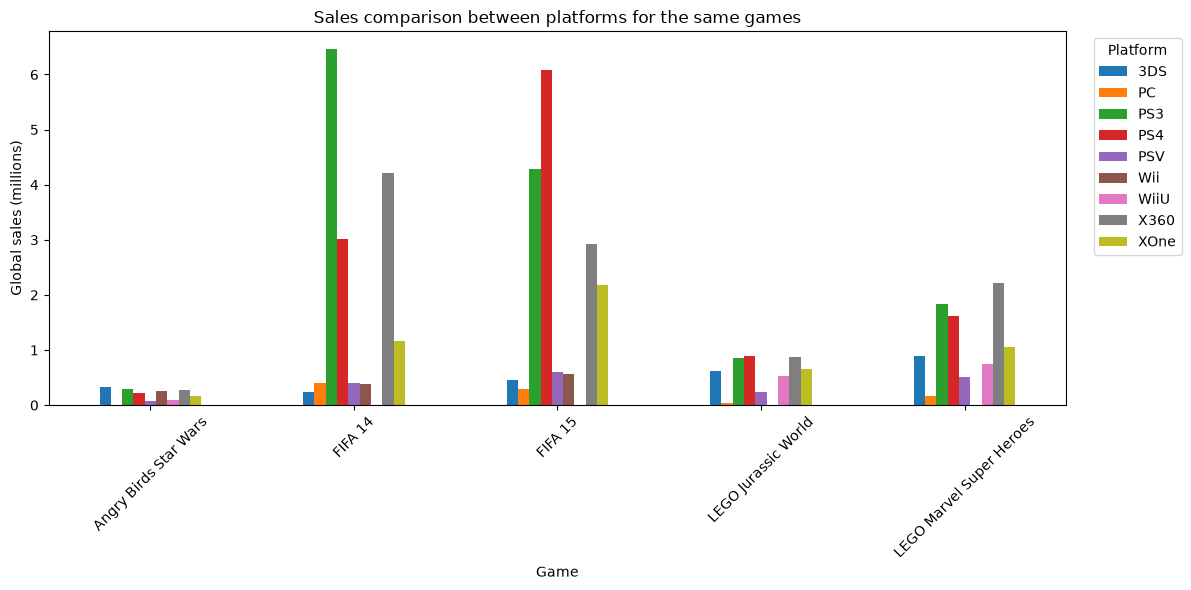

In [194]:
 # creating a chart to analyze
df_5_pivot.plot(kind='bar', figsize=(12,6),
                 title='Sales comparison between platforms for the same games',
                 xlabel='Game',
                 ylabel='Global sales (millions)',
                 rot=45)
plt.legend(title='Platform', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Comparing the games**

Even though it's the same game, on some specific platforms the sales revenue is dramatically higher. For example, FIFA 14 and FIFA 15 were very successful on PS3 and PS4, but had modest revenue on the 3DS platform.

This chart also helps illustrate a platform transition from PS3 to PS4 with the update from FIFA 14 to FIFA 15.


### Investigating the overall distribution of games by genre to identify the most profitable genres?


In [195]:
# creating a df grouped by genre based on total revenue
df_genre = (
    df.groupby('genre')['total_sales_milions'].sum()
    .reset_index()
).sort_values('total_sales_milions', ascending=False)

df_genre = df_genre.reset_index(drop=True)

print(df_genre)


           genre  total_sales_milions
0         Action               320.51
1        Shooter               232.98
2         Sports               149.93
3   Role-Playing               144.86
4           Misc                62.57
5       Platform                41.94
6         Racing                39.89
7       Fighting                35.29
8      Adventure                22.90
9     Simulation                21.55
10      Strategy                10.06
11        Puzzle                 3.17


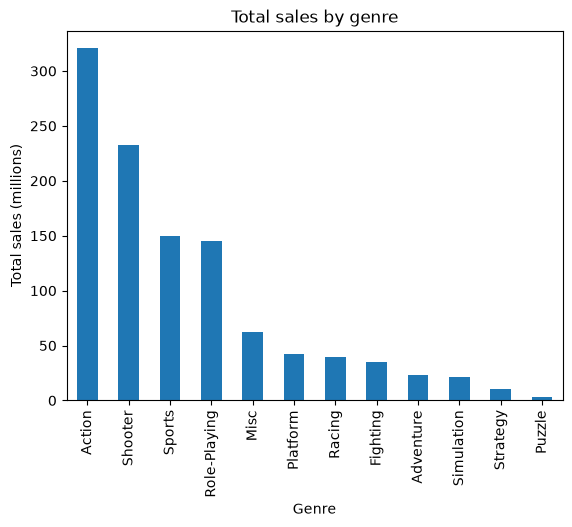

In [196]:
df_genre.plot(x='genre', kind='bar',
             title='Total sales by genre',
             xlabel='Genre',
             ylabel='Total sales (millions)',
             legend=False)
plt.show()


**About the genre distribution**

Overall, Action games generated the highest revenue, followed by Shooter, Sports, and RPG.

Considering that Strategy and Puzzle games are the lowest-revenue genres, one could generalize about genres being higher or lower based on how much action they provide or generate.

However, considering that two genres that require concentration (Shooter and RPG) ranked second and fourth in revenue, it may be worth investigating these two genres further before confirming that generalization.


## Analyzing the user profile for each region


### NA Region


#### Describing market share for the top 5 platforms


In [197]:
# gathering data on platform revenue in the region
na_plat = (
    df.groupby('platform')['na_sales_milions'].sum().reset_index()
    .sort_values('na_sales_milions', ascending=False)
)
na_plat = na_plat.reset_index(drop=True)
print(na_plat.head(5))


  platform  na_sales_milions
0      PS4            108.74
1     XOne             93.12
2     X360             81.66
3      PS3             63.50
4      3DS             38.20


In [198]:
# getting the percentage of their market share in the region
na_plat['participation_%'] = (na_plat['na_sales_milions'] / na_plat['na_sales_milions'].sum()*100).round(2)

print(na_plat)


  platform  na_sales_milions  participation_%
0      PS4            108.74            24.88
1     XOne             93.12            21.30
2     X360             81.66            18.68
3      PS3             63.50            14.53
4      3DS             38.20             8.74
5     WiiU             29.21             6.68
6       PC             11.11             2.54
7      Wii              6.56             1.50
8      PSV              5.04             1.15


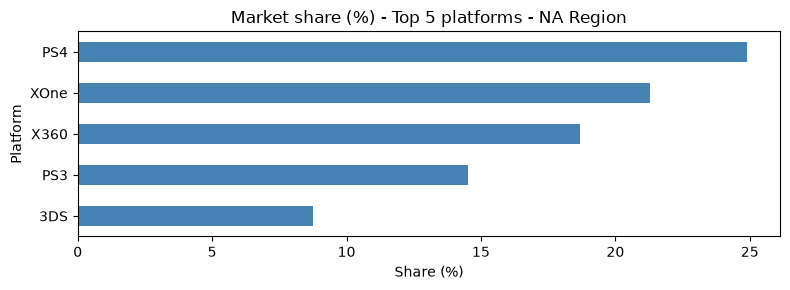

In [199]:
# bar chart with the top 5 platforms' market share in the NA region
top5_na = na_plat.head(5)

top5_na.plot(x='platform', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='steelblue',
             title='Market share (%) - Top 5 platforms - NA Region',
             xlabel='Share (%)', ylabel='Platform')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Explaining the difference between the top five genres


In [200]:
# gathering data on revenue by genre in the region
na_genre = (
    df.groupby('genre')['na_sales_milions'].sum().reset_index()
    .sort_values('na_sales_milions', ascending=False)
).reset_index(drop=True)

print(na_genre)


           genre  na_sales_milions
0         Action            125.83
1        Shooter            109.74
2         Sports             65.27
3   Role-Playing             46.40
4           Misc             27.46
5       Platform             17.93
6       Fighting             15.55
7         Racing             12.96
8      Adventure              7.14
9     Simulation              4.75
10      Strategy              3.28
11        Puzzle              0.83


In [201]:
# getting the percentage of their market share in the region
na_genre['participation_%'] = (na_genre['na_sales_milions'] /
                               na_genre['na_sales_milions'].sum()*100).round(2)

print(na_genre)


           genre  na_sales_milions  participation_%
0         Action            125.83            28.78
1        Shooter            109.74            25.10
2         Sports             65.27            14.93
3   Role-Playing             46.40            10.61
4           Misc             27.46             6.28
5       Platform             17.93             4.10
6       Fighting             15.55             3.56
7         Racing             12.96             2.96
8      Adventure              7.14             1.63
9     Simulation              4.75             1.09
10      Strategy              3.28             0.75
11        Puzzle              0.83             0.19


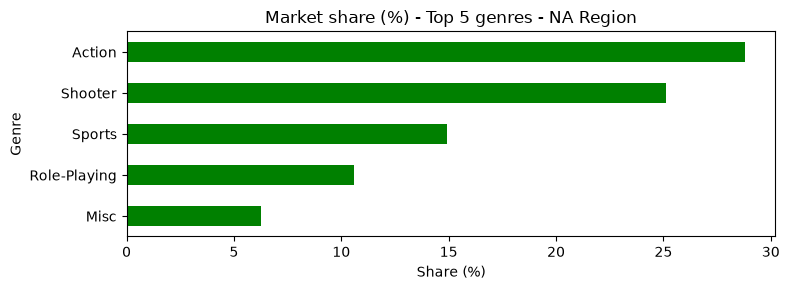

In [202]:
# bar chart with the top 5 genres' market share in the NA region
top5_genre_na = na_genre.head(5)

top5_genre_na.plot(x='genre', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='green',
             title='Market share (%) - Top 5 genres - NA Region',
             xlabel='Share (%)', ylabel='Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Do ESRB ratings affect sales


In [203]:
# gathering data on ESRB ratings and sales in the region
esrb_na = (
    df.groupby('rating')['na_sales_milions'].sum().reset_index()
    .sort_values('na_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print(esrb_na)


  rating  na_sales_milions
0      M            165.21
1      E             78.94
2   E10+             54.02
3      T             49.79


* as explained in the corresponding section, missing values were filtered out of the 'rating' column at this point to produce relevant information.
* it's worth noting that some outdated rating values remain, but they are being treated as the current rating for this analysis.


In [204]:
# getting the percentage of their market share in the region
esrb_na['participation_%'] = (
    esrb_na['na_sales_milions'] / df['na_sales_milions'].sum() * 100
).round(2)
print(esrb_na)


  rating  na_sales_milions  participation_%
0      M            165.21            37.79
1      E             78.94            18.06
2   E10+             54.02            12.36
3      T             49.79            11.39


* for the total market share, the sum of sales in the region was considered including those with missing values in the 'rating' column


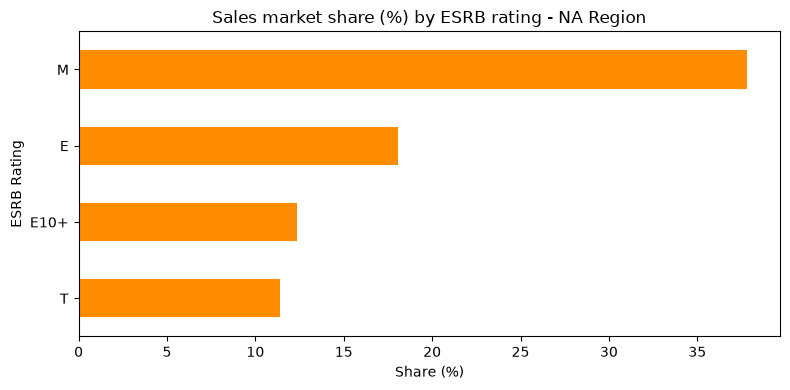

In [205]:
# bar chart with ESRB rating market share in the region
esrb_na.plot(x='rating', y='participation_%', kind='barh',
             figsize=(8,4), legend=False, color='darkorange',
             title='Sales market share (%) by ESRB rating - NA Region',
             xlabel='Share (%)', ylabel='ESRB Rating')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Summary of the NA region**

**About market share:**
The top five platforms in the NA region were PS4, XOne, X360, PS3, and 3DS, with the combined share of these 5 platforms exceeding 85% of the region's market.

**About the main genres:**
Approximately 70% of this region's market is dominated by the top 5 genres.
Action games dominate the market in this region. Since 'Shooter' ranks second, it's expected to be associated with action, given that Sports ranks third.
The top 5 in this region follows the same order as the overall top 5.

**About the ESRB rating:**
Of the total sales in the region that had an ESRB rating, it's possible to see the prevalence of the M audience (ages 17+) in sales volume. This suggests that this region's sales share by rating skews mostly toward an M audience.


## EU Region


#### Describing market share for the top 5 platforms


In [206]:
# gathering data on platform revenue in the region
eu_plat = (
    df.groupby('platform')['eu_sales_milions'].sum().reset_index()
    .sort_values('eu_sales_milions', ascending=False)
)
eu_plat = eu_plat.reset_index(drop=True)
print(eu_plat.head(5))


  platform  eu_sales_milions
0      PS4            141.09
1      PS3             67.81
2     XOne             51.59
3     X360             42.52
4      3DS             30.96


In [207]:
# getting the percentage of their market share in the region
eu_plat['participation_%'] = (
    eu_plat['eu_sales_milions']/ eu_plat['eu_sales_milions'].sum()*100
).round(2)

print(eu_plat)


  platform  eu_sales_milions  participation_%
0      PS4            141.09            36.07
1      PS3             67.81            17.33
2     XOne             51.59            13.19
3     X360             42.52            10.87
4      3DS             30.96             7.91
5       PC             25.36             6.48
6     WiiU             19.85             5.07
7      PSV              6.10             1.56
8      Wii              5.93             1.52


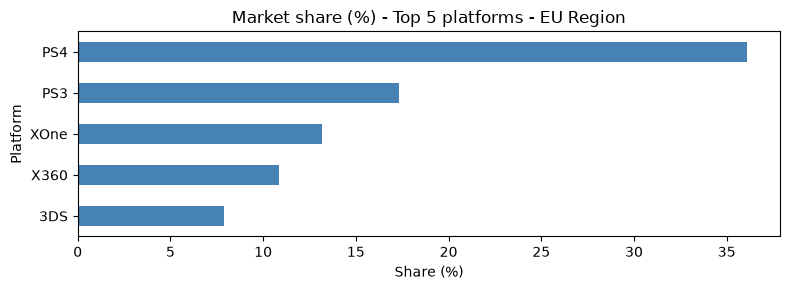

In [208]:
# bar chart with the top 5 platforms' market share in the region
top5_eu = eu_plat.head(5)

top5_eu.plot(x='platform', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='steelblue',
             title='Market share (%) - Top 5 platforms - EU Region',
             xlabel='Share (%)', ylabel='Platform')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Explaining the difference between the top five genres


In [209]:
# gathering data on revenue by genre in the region
eu_genre = (
    df.groupby('genre')['eu_sales_milions'].sum().reset_index()
    .sort_values('eu_sales_milions', ascending=False)
).reset_index(drop=True)

print(eu_genre)


           genre  eu_sales_milions
0         Action            117.87
1        Shooter             87.86
2         Sports             60.34
3   Role-Playing             36.97
4         Racing             20.19
5           Misc             20.00
6       Platform             15.15
7     Simulation             10.84
8       Fighting              8.55
9      Adventure              8.22
10      Strategy              4.22
11        Puzzle              1.00


In [210]:
# getting the percentage of their market share in the region
eu_genre['participation_%'] = (
    eu_genre['eu_sales_milions'] / eu_genre['eu_sales_milions'].sum()*100
).round(2)

print(eu_genre)


           genre  eu_sales_milions  participation_%
0         Action            117.87            30.13
1        Shooter             87.86            22.46
2         Sports             60.34            15.42
3   Role-Playing             36.97             9.45
4         Racing             20.19             5.16
5           Misc             20.00             5.11
6       Platform             15.15             3.87
7     Simulation             10.84             2.77
8       Fighting              8.55             2.19
9      Adventure              8.22             2.10
10      Strategy              4.22             1.08
11        Puzzle              1.00             0.26


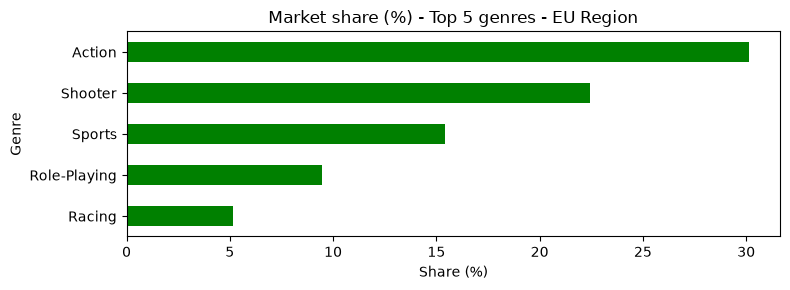

In [211]:
# bar chart with the top 5 genres' market share in the EU region
top5_genre_eu = eu_genre.head(5)

top5_genre_eu.plot(x='genre', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='green',
             title='Market share (%) - Top 5 genres - EU Region',
             xlabel='Share (%)', ylabel='Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Do ESRB ratings affect sales


In [212]:
# gathering data on ESRB ratings and sales in the region
esrb_eu = (
    df.groupby('rating')['eu_sales_milions'].sum().reset_index()
    .sort_values('eu_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print(esrb_eu)


  rating  eu_sales_milions
0      M            145.32
1      E             82.80
2   E10+             42.53
3      T             41.95


* as explained in the corresponding section, missing values were filtered out of the 'rating' column at this point to produce relevant information.
* it's worth noting that some outdated rating values remain, but they are being treated as the current rating for this analysis.


In [213]:
# getting the percentage of their market share in the region
esrb_eu['participation_%'] = (
    esrb_eu['eu_sales_milions'] / df['eu_sales_milions'].sum() * 100
).round(2)

print(esrb_eu)


  rating  eu_sales_milions  participation_%
0      M            145.32            37.15
1      E             82.80            21.17
2   E10+             42.53            10.87
3      T             41.95            10.72


* for the total market share, the sum of sales in the region was considered including those with missing values in the 'rating' column


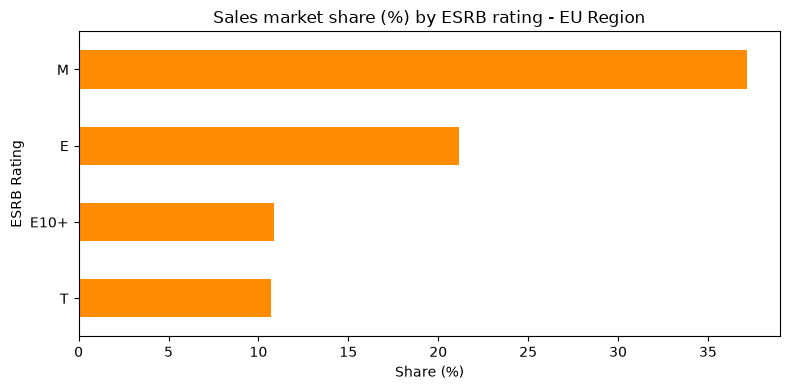

In [214]:
# bar chart with ESRB rating market share in the region
esrb_eu.plot(x='rating', y='participation_%', kind='barh',
             figsize=(8,4), legend=False, color='darkorange',
             title='Sales market share (%) by ESRB rating - EU Region',
             xlabel='Share (%)', ylabel='ESRB Rating')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Summary of the EU region**

**About market share:**
The top five platforms in the EU region were PS4, PS3, XOne, X360, and 3DS, with the combined share of these 5 platforms exceeding 85% of the region's market.

**About the main genres:**
Approximately 70% of this region's market is dominated by the top 5 genres.
Action games dominate the market in this region. Since 'Shooter' ranks second, it's expected to be associated with action, given that Sports ranks third.
The top 5 behavior in this region is very similar to the NA region, with the notable difference that in the EU, Racing takes fifth place.

**About the ESRB rating:**
Of the total sales in the region that had an ESRB rating, it's possible to see the prevalence of the M audience (ages 17+) in sales volume. This suggests that this region's sales share by rating skews mostly toward an M audience.


## JP Region


#### Describing market share for the top 5 platforms


In [215]:
# gathering data on platform revenue in the region
jp_plat = (
    df.groupby('platform')['jp_sales_milions'].sum().reset_index()
    .sort_values('jp_sales_milions', ascending=False)
)
jp_plat = jp_plat.reset_index(drop=True)
print(jp_plat.head(5))


  platform  jp_sales_milions
0      3DS             67.81
1      PS3             23.35
2      PSV             18.59
3      PS4             15.96
4     WiiU             10.88


In [216]:
# getting the percentage of their market share in the region
jp_plat['participation_%'] = (
    jp_plat['jp_sales_milions'] / jp_plat['jp_sales_milions'].sum()*100
).round(2)

print(jp_plat)


  platform  jp_sales_milions  participation_%
0      3DS             67.81            49.32
1      PS3             23.35            16.98
2      PSV             18.59            13.52
3      PS4             15.96            11.61
4     WiiU             10.88             7.91
5     X360              0.51             0.37
6     XOne              0.34             0.25
7      Wii              0.05             0.04
8       PC              0.00             0.00


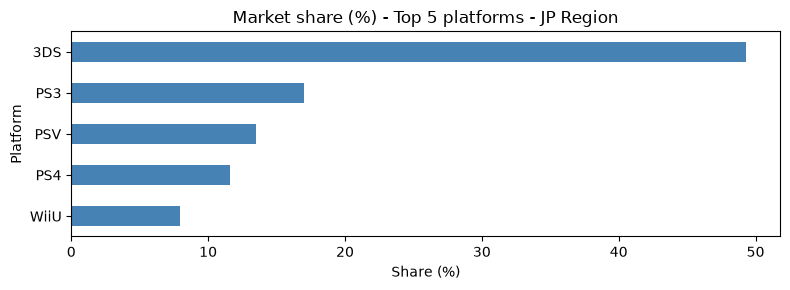

In [217]:
# bar chart with the top 5 platforms' market share in the region
top5_jp = jp_plat.head(5)

top5_jp.plot(x='platform', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='steelblue',
             title='Market share (%) - Top 5 platforms - JP Region',
             xlabel='Share (%)', ylabel='Platform')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Explaining the difference between the top five genres


In [218]:
# gathering data on revenue by genre in the region
jp_genre = (
    df.groupby('genre')['jp_sales_milions'].sum().reset_index()
    .sort_values('jp_sales_milions', ascending=False)
).reset_index(drop=True)

print(jp_genre)


           genre  jp_sales_milions
0   Role-Playing             50.01
1         Action             39.65
2           Misc              9.03
3       Fighting              7.63
4        Shooter              6.61
5      Adventure              5.11
6         Sports              4.91
7       Platform              4.79
8     Simulation              4.52
9         Racing              2.30
10      Strategy              1.75
11        Puzzle              1.18


In [219]:
# getting the percentage of their market share in the region
jp_genre['participation_%'] = (
    jp_genre['jp_sales_milions'] / jp_genre['jp_sales_milions'].sum()*100
).round(2)

print(jp_genre)


           genre  jp_sales_milions  participation_%
0   Role-Playing             50.01            36.37
1         Action             39.65            28.84
2           Misc              9.03             6.57
3       Fighting              7.63             5.55
4        Shooter              6.61             4.81
5      Adventure              5.11             3.72
6         Sports              4.91             3.57
7       Platform              4.79             3.48
8     Simulation              4.52             3.29
9         Racing              2.30             1.67
10      Strategy              1.75             1.27
11        Puzzle              1.18             0.86


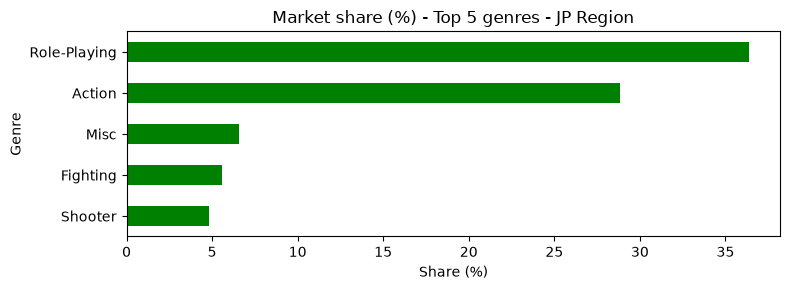

In [220]:
# bar chart with the top 5 genres' market share in the JP region
top5_genre_jp = jp_genre.head(5)

top5_genre_jp.plot(x='genre', y='participation_%', kind='barh',
             figsize=(8,3), legend=False, color='green',
             title='Market share (%) - Top 5 genres - JP Region',
             xlabel='Share (%)', ylabel='Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Do ESRB ratings affect sales


In [221]:
# gathering data on ESRB ratings and sales in the region
esrb_jp = (
    df.groupby('rating')['jp_sales_milions'].sum().reset_index()
    .sort_values('jp_sales_milions', ascending=False)
    .reset_index(drop=True)
)

print(esrb_jp)


  rating  jp_sales_milions
0      T             20.44
1      E             15.00
2      M             14.11
3   E10+              5.89


* as explained in the corresponding section, missing values were filtered out of the 'rating' column at this point to produce relevant information.
* it's worth noting that some outdated rating values remain, but they are being treated as the current rating for this analysis.


In [222]:
# getting the percentage of their market share in the region
esrb_jp['participation_%'] = (
    esrb_jp['jp_sales_milions'] / df['jp_sales_milions'].sum() * 100
).round(2)

print(esrb_jp)


  rating  jp_sales_milions  participation_%
0      T             20.44            14.87
1      E             15.00            10.91
2      M             14.11            10.26
3   E10+              5.89             4.28


* for the total market share, the sum of sales in the region was considered including those with missing values in the 'rating' column


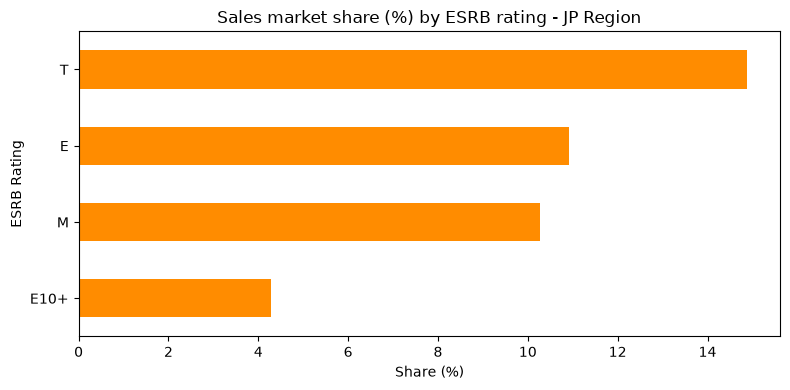

In [223]:
# bar chart with ESRB rating market share in the region
esrb_jp.plot(x='rating', y='participation_%', kind='barh',
             figsize=(8,4), legend=False, color='darkorange',
             title='Sales market share (%) by ESRB rating - JP Region',
             xlabel='Share (%)', ylabel='ESRB Rating')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Summary of the JP region**

**About market share:**
The top five platforms in the JP region were 3DS, PS3, PSV, PS4, and WiiU, with the combined share of these 5 platforms exceeding 97% of the region's market.

Although PS4 and XOne are the only platforms showing a growth trend, this region shows different behavior. There appears to be a longer latency period here for console turnover — older predecessors hold onto a significant share of the market.

This needs further study, since it could be a traditional behavior in this region or a delay in the release of new games and platforms here. Whatever the reason, it will be necessary to understand it in order to position strategically.

**About the main genres:**
Approximately 70% of this region's market is dominated by the top 5 genres. This region, however, shows a very distinct genre selection compared to the others — Action games still hold a large share, but Role-Playing games capture approximately 30% of the market.

This phenomenon may help explain why older consoles are retained longer, since this genre isn't as instant-gratification oriented. It requires more time investment to follow the story and tends to accompany the user's growth for longer, generating stronger loyalty.

**About the ESRB rating:**
Unlike other regions, the T audience (ages 13+) has a larger share of sales volume, and the distribution across ESRB ratings is more even.
So, unlike other regions, this region's sales share by rating leans more strongly toward a younger T audience, though sales are better distributed across the other audiences as well. This difference should be noted as a distinct market niche.


## Hypothesis testing


#### Defining the significance level for hypothesis testing.

For both cases, the significance value (alpha) will be 0.05. A significance value of 0.05 is a conventional standard for exploratory data and business analysis. This balances the risk of a false positive against being overly conservative.

Additionally, there's no specific reason here (health or safety related) to set as strict a significance level as 0.01.


In [224]:
# Parameters
alpha = 0.05


### The average user ratings for the Xbox One and PC platforms are the same.


**Hypotheses**

* $H_0$ = the average user ratings for Xbox One and PC are equal.
* $H_1$ = the average user ratings for Xbox One and PC are different.


For a t-test, the null hypothesis $H_0$ is always the statement of similarity (the events cause no change), and the alternative hypothesis $H_1$ represents what we're seeking evidence to support.

This will be a two-tailed test, since the question is only to find out whether the averages are the same or not, without specifying a direction.


In [225]:
# preparing the data: user_score by platform, removing missing values
xone_scores = df[df['platform'] == 'XOne']['user_score_max10'].dropna()
pc_scores = df[df['platform'] == 'PC']['user_score_max10'].dropna()


In [226]:
# assessing the samples under study
print('Xbox One:', len(xone_scores),
      'rows with variance of:', np.var(xone_scores).round(2))

print('PC:', len(pc_scores),
      'rows with variance of:', np.var(pc_scores).round(2))


Xbox One: 182 rows with variance of: 1.9
PC: 155 rows with variance of: 3.02


equal_var should be set to False, since the samples have different sizes and variances. Setting this to True would make that assumption even weaker.


In [227]:
# Welch's t-test (does not assume equal variances between the two groups)
results_platform = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print('p-value:', results_platform.pvalue)

if results_platform.pvalue < alpha:
    print('We reject the null hypothesis: the average ratings are different')
else:
    print('We fail to reject the null hypothesis: there is not enough evidence of a difference in average ratings')


p-value: 0.1475959401343046
We fail to reject the null hypothesis: there is not enough evidence of a difference in average ratings


**Test conclusion**

Since the p-value (0.15) was much higher than the established alpha (0.05), the null hypothesis that Xbox One's and PC's average user ratings are equal cannot be rejected.

Therefore, it should be considered that there isn't enough evidence of a difference between Xbox One's and PC's average user ratings.


### The average user ratings for the Action and Sports genres are different.


**Hypotheses**

* $H_0$ = the average user ratings for the Action and Sports genres are equal
* $H_1$ = the average user ratings for the Action and Sports genres are different


For a t-test, the null hypothesis $H_0$ is always the statement of similarity (the events cause no change), and the alternative hypothesis $H_1$ represents what we're seeking evidence to support.

This will be a two-tailed test, since the question is only to find out whether the averages are the same or not, without specifying a direction.


In [228]:
# preparing the data: user_score by genre, removing missing values
action_scores = df[df['genre'] == 'Action']['user_score_max10'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score_max10'].dropna()


In [229]:
# assessing the samples under study
print('Action:', len(action_scores),
      'rows with variance of:', np.var(action_scores).round(2))

print('Sports:', len(sports_scores),
      'rows with variance of:', np.var(sports_scores).round(2))


Action: 388 rows with variance of: 1.76
Sports: 159 rows with variance of: 3.16


equal_var should be set to False, since the samples have different sizes and variances. Setting this to True would make that assumption even weaker.


In [230]:
# Welch's t-test
results_genre = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print('p-value:', results_genre.pvalue)

if results_genre.pvalue < alpha:
    print('We reject the null hypothesis: the average ratings are different')
else:
    print('We fail to reject the null hypothesis: there is not enough evidence of a difference in average ratings')


p-value: 2.4191414517472394e-20
We reject the null hypothesis: the average ratings are different


**Test conclusion**

Since the p-value (1e-20) was much lower than the established alpha (0.05), the null hypothesis that the average user ratings for the Action and Sports genres are equal is rejected.

Therefore, it should be considered that the average user ratings for the Action and Sports genres are different.


# General Conclusion


**About the data:** the original dataset contained game sales from 1980 to 2016. After handling missing and duplicated data, the analysis period was restricted to 2013–2016 (reflecting the most recent sales plateau), and only platforms with revenue in 2016 were kept.

**Platform lifecycle:** a platform's lifespan ranges from 3 to 31 years, averaging approximately 9.5 years, reflecting a clear pattern of generational succession.

**Leading and potentially profitable platforms:** in the 2013–2016 period, only PS4 and XOne showed a growth trend, making them the most promising bets for the next cycle. The top 5 were PS4, PS3, XOne, 3DS, and X360.

**Sales distribution by platform:** strong right skew across all platforms (median generally below 0.5 million copies), statistically confirmed by the Kruskal-Wallis test (p ≈ 0.0000). The median, not the mean, is the more reliable metric.

**Reviews and sales (PS4):** very weak correlation with user reviews (≈ 0.03) and moderate correlation with critic reviews (≈ 0.41) — professional reviews carry more weight in purchase decisions.

**Same game, different platforms:** the same title can perform very differently depending on the platform (e.g., FIFA 14/15 illustrates the PS3 → PS4 transition).

**Most profitable genres:** Action leads, followed by Shooter, Sports, and RPG — preventing a simplistic generalization that "action = sales," since regional profile has a strong influence on this question.

**Regional profiles:** NA and EU are similar (PS4/XOne/X360 lead, Action/Shooter dominate genres, M audience leads ESRB). JP is much more concentrated (3DS at 48%!), RPG dominates genres, T audience leads ESRB — a distinct profile that calls for its own strategy.

**Hypothesis tests:** H₀ is not rejected for Xbox One vs. PC (p ≈ 0.15) — not enough evidence of a difference; H₀ is rejected for Action vs. Sports (p ≈ 1e-20) — different ratings.

**Strategic recommendation:** prioritize PS4/XOne, focus on Action/Shooter/Sports/RPG by region, give more weight to professional reviews in marketing, and always keep the data's time window aligned with the business decision horizon.

